In [5]:
import os

os.getcwd()

'C:\\Users\\jose1\\OneDrive\\Área de Trabalho\\Portifólio\\brazilian-municipal-data-analysis\\notebooks'

# Brazilian Municipal Data Analysis

## Data Cleaning, Exploration and Visualization with Python

This project demonstrates the process of cleaning, organizing, exploring and visualizing Brazilian municipal data using Python.

### Objectives

- Import and inspect raw data
- Identify missing values and duplicated observations
- Clean and organize variables
- Create descriptive statistics
- Produce meaningful visualizations
- Generate insights from municipal-level data

### Tools

- Python
- Pandas
- NumPy
- Matplotlib

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Project paths

PROJECT_DIR = Path.cwd().parent
DATA_DIR = PROJECT_DIR / "data"
FIGURES_DIR = PROJECT_DIR / "figures"

print("Project directory:", PROJECT_DIR)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)

Project directory: C:\Users\jose1\OneDrive\Área de Trabalho\Portifólio\brazilian-municipal-data-analysis
Data directory: C:\Users\jose1\OneDrive\Área de Trabalho\Portifólio\brazilian-municipal-data-analysis\data
Figures directory: C:\Users\jose1\OneDrive\Área de Trabalho\Portifólio\brazilian-municipal-data-analysis\figures


## 1. Data Preparation

The original dataset contains Brazilian municipal-level information organized as panel data.

For portfolio purposes, a reduced sample of municipalities is used. This keeps the project lightweight and reproducible while preserving the panel structure of the original data.

In [9]:
df = pd.read_csv(r"C:\Users\jose1\OneDrive\Área de Trabalho\artigo DADOS DE Crédito, Emprego e do BNDES\BNDES_DESEMBOLSO_2008-2026.csv") 

C:\Users\jose1\AppData\Local\Temp\ipykernel_8688\191512029.py:1: DtypeWarning: Columns (0,10,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\jose1\OneDrive\Área de Trabalho\artigo DADOS DE Crédito, Emprego e do BNDES\BNDES_DESEMBOLSO_2008-2026.csv")


In [10]:
df.describe()

,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
count,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927,3591927.0
unique,45,13,3,15,269,3,5,6,28,5264,10944,5,46,5,21,1881148.0
top,2013,DEZEMBRO,INDIRETA,CARTÃO BNDES,CARTÃO BNDES,NÃO,MICRO,SUL,SAO PAULO,SAO PAULO,3550308,COMÉRCIO E SERVIÇOS,AGROPECUÁRIA,COMÉRCIO E SERVIÇOS,COMÉRCIO E SERVIÇOS,100000.0
freq,327680,327596,3540637,1483174,1483174,3572489,2012044,1363255,683949,39329,33747,1891297,902937,1338597,1338597,21052.0


In [11]:
print("Dimensão da base:")
print(df.shape)

print("\nNomes das colunas:")
for i, col in enumerate(df.columns):
    print(i, "-", col)

Dimensão da base:
(3591943, 16)

Nomes das colunas:
0 - ANO
1 - MÊS
2 - FORMA DE APOIO
3 - PRODUTO
4 - INSTRUMENTO FINANCEIRO
5 - INOVAÇÃO
6 - PORTE DE EMPRESA
7 - REGIÃO
8 - UF
9 - MUNICÍPIO
10 - MUNICÍPIO - CÓDIGO
11 - SETOR CNAE
12 - SUBSETOR CNAE AGRUPADO
13 - SETOR BNDES
14 - SUBSETOR BNDES
15 - DESEMBOLSOS
(R$)


In [13]:
df.head()

,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
0,2008,DEZEMBRO,DIRETA,BNDES-EXIM,BNDES EXIM PÓS-EMBARQUE – Buyer’s Credit,NÃO,GRANDE,NORDESTE,BAHIA,SALVADOR,2927408,COMÉRCIO E SERVIÇOS,CONSTRUÇÃO,COMÉRCIO E SERVIÇOS,COMÉRCIO E SERVIÇOS,1868269.01
1,2008,DEZEMBRO,DIRETA,BNDES-EXIM,BNDES EXIM PÓS-EMBARQUE – Buyer’s Credit,NÃO,GRANDE,SUDESTE,MINAS GERAIS,BELO HORIZONTE,3106200,COMÉRCIO E SERVIÇOS,CONSTRUÇÃO,COMÉRCIO E SERVIÇOS,COMÉRCIO E SERVIÇOS,24076557.29
2,2008,DEZEMBRO,DIRETA,BNDES-EXIM,BNDES EXIM PÓS-EMBARQUE – Buyer’s Credit,NÃO,GRANDE,SUDESTE,RIO DE JANEIRO,RIO DE JANEIRO,3304557,COMÉRCIO E SERVIÇOS,CONSTRUÇÃO,COMÉRCIO E SERVIÇOS,COMÉRCIO E SERVIÇOS,246568439.72
3,2008,DEZEMBRO,DIRETA,BNDES-EXIM,BNDES EXIM PÓS-EMBARQUE – Buyer’s Credit,NÃO,GRANDE,SUDESTE,SAO PAULO,SAO JOSE DOS CAMPOS,3549904,INDÚSTRIA DE TRANSFORMAÇÃO,OUTROS EQUIP TRANSPORTE,INDUSTRIA,MATERIAL DE TRANSPORTE,539282817.39
4,2008,DEZEMBRO,DIRETA,BNDES-EXIM,BNDES EXIM PÓS-EMBARQUE – Buyer’s Credit,NÃO,GRANDE,SUDESTE,SAO PAULO,SAO PAULO,3550308,COMÉRCIO E SERVIÇOS,CONSTRUÇÃO,COMÉRCIO E SERVIÇOS,COMÉRCIO E SERVIÇOS,9738311.62


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3591943 entries, 0 to 3591942
Data columns (total 16 columns):
 #   Column                  Dtype 
---  ------                  ----- 
 0   ANO                     object
 1   MÊS                     object
 2   FORMA DE APOIO          object
 3   PRODUTO                 object
 4   INSTRUMENTO FINANCEIRO  object
 5   INOVAÇÃO                object
 6   PORTE DE EMPRESA        object
 7   REGIÃO                  object
 8   UF                      object
 9   MUNICÍPIO               object
 10  MUNICÍPIO - CÓDIGO      object
 11  SETOR CNAE              object
 12  SUBSETOR CNAE AGRUPADO  object
 13  SETOR BNDES             object
 14  SUBSETOR BNDES          object
 15  DESEMBOLSOS
(R$)        object
dtypes: object(16)
memory usage: 438.5+ MB


In [15]:
df_raw = df.copy()

## 3. Data Quality Assessment

Before cleaning the datasetIwe inspect its structure and identify potential inconsistencies in variable names, data types, missing values and categorical values.

This step is important because transformations should only be performed after understanding the issues present in the raw data.

In [21]:
# Mostrar os nomes exatamente como foram lidos pelo Pandas
for i, col in enumerate(df.columns):
    print(i, repr(col))

0 'ANO'
1 'MÊS'
2 'FORMA DE APOIO'
3 'PRODUTO'
4 'INSTRUMENTO FINANCEIRO'
5 'INOVAÇÃO'
6 'PORTE DE EMPRESA'
7 'REGIÃO'
8 'UF'
9 'MUNICÍPIO'
10 'MUNICÍPIO - CÓDIGO'
11 'SETOR CNAE'
12 'SUBSETOR CNAE AGRUPADO'
13 'SETOR BNDES'
14 'SUBSETOR BNDES'
15 'DESEMBOLSOS\n(R$)'


In [23]:
# Inspecionar especificamente as colunas que geraram o warning

problem_cols = [
    df.columns[0],
    df.columns[10],
    df.columns[15]
]

for col in problem_cols:
    print("\n" + "=" * 60)
    print("COLUNA:", repr(col))
    print("Tipo geral:", df[col].dtype)
    print("Valores ausentes:", df[col].isna().sum())
    print("\nExemplos:")
    print(df[col].dropna().sample(
        min(15, df[col].notna().sum()),
        random_state=42
    ).tolist())


COLUNA: 'ANO'
Tipo geral: object
Valores ausentes: 16

Exemplos:
['2015', '2023', 2009, 2020, 2023, 2013, 2008, 2015, 2010, 2011, 2014, '2022', 2012, 2003, 2014]

COLUNA: 'MUNICÍPIO - CÓDIGO'
Tipo geral: object
Valores ausentes: 16

Exemplos:
['4101408', '4302501', 3510005, 4126801, 3116605, 4322509, 3151503, 2910701, 1100122, 2931350, 4119103, '2208007', 4203006, 5006606, 3148004]

COLUNA: 'DESEMBOLSOS\n(R$)'
Tipo geral: object
Valores ausentes: 16

Exemplos:
['116884.59', '325689.41', 58400.0, 51892.2, 868090.25, 3000000.0, 406980.0, 10068.3, 121650.0, 4453875.78, 117000.0, '4565399.8', 71515.88, 1226123.5, 5359.04]


### Identification of Mixed Data Types

During the initial inspection, some variables were found to contain mixed data types.

For example, year and municipality codes were stored partly as numeric values and partly as strings. These inconsistencies must be identified before converting the variables to appropriate formats.

In [25]:
df["ANO"].map(type).value_counts()

ANO
<class 'int'>      3067655
<class 'str'>       524272
<class 'float'>         16
Name: count, dtype: int64

### 

In [27]:
df["MUNICÍPIO - CÓDIGO"].map(type).value_counts()

MUNICÍPIO - CÓDIGO
<class 'int'>      3067655
<class 'str'>       524272
<class 'float'>         16
Name: count, dtype: int64

In [29]:
# Convert temporarily to string ONLY for inspection
ano_temp = df["ANO"].dropna().astype(str).str.strip()

print("Valores encontrados em ANO:")
print(sorted(ano_temp.unique()))

print("\nNúmero de valores distintos após padronização:")
print(ano_temp.nunique())

Valores encontrados em ANO:
['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', 'ANO']

Número de valores distintos após padronização:
26


In [31]:
mes_temp = df["MÊS"].dropna().astype(str).str.strip()

print("Valores encontrados em MÊS:")
print(sorted(mes_temp.unique()))

print("\nNúmero de valores distintos:")
print(mes_temp.nunique())

Valores encontrados em MÊS:
['ABRIL', 'AGOSTO', 'DEZEMBRO', 'FEVEREIRO', 'JANEIRO', 'JULHO', 'JUNHO', 'MAIO', 'MARÇO', 'MÊS', 'NOVEMBRO', 'OUTUBRO', 'SETEMBRO']

Número de valores distintos:
13


In [33]:
ano_numerico = pd.to_numeric(df["ANO"], errors="coerce")

problemas_ano = df.loc[
    df["ANO"].notna() & ano_numerico.isna(),
    "ANO"
]

print("Valores de ANO que não puderam ser convertidos:")
print(problemas_ano.value_counts().head(30))

Valores de ANO que não puderam ser convertidos:
ANO
ANO    16
Name: count, dtype: int64


In [35]:
cod_numerico = pd.to_numeric(
    df["MUNICÍPIO - CÓDIGO"],
    errors="coerce"
)

problemas_codigo = df.loc[
    df["MUNICÍPIO - CÓDIGO"].notna() & cod_numerico.isna(),
    "MUNICÍPIO - CÓDIGO"
]

print("Códigos municipais que não puderam ser convertidos:")
print(problemas_codigo.value_counts().head(30))

Códigos municipais que não puderam ser convertidos:
MUNICÍPIO - CÓDIGO
MUNICÍPIO - CÓDIGO    16
Name: count, dtype: int64


In [37]:
col_valor = df.columns[15]

valor_numerico = pd.to_numeric(
    df[col_valor],
    errors="coerce"
)

problemas_valor = df.loc[
    df[col_valor].notna() & valor_numerico.isna(),
    col_valor
]

print("Valores de desembolso que não puderam ser convertidos:")
print(problemas_valor.value_counts().head(30))

Valores de desembolso que não puderam ser convertidos:
DESEMBOLSOS\n(R$)
DESEMBOLSOS\n(R$)    16
Name: count, dtype: int64


In [39]:
# Inspect rows that appear to be repeated headers

header_rows = df[
    df["ANO"].astype(str).str.strip().eq("ANO")
]

print("Number of repeated header rows:", len(header_rows))

header_rows.head(20)

Number of repeated header rows: 16


,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
433198,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
796188,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
1068011,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
1373915,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
1714492,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
2042270,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
2319527,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
2674737,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
2806968,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
2926044,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)


In [41]:
print("Completely empty rows:")
print(df.isna().all(axis=1).sum())

Completely empty rows:
16


In [43]:
df[df["ANO"].isna()].head(50)

,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
433197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
796187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1068010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1373914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1714491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2042269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2319526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2674736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2806967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2926043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
df_raw = df.copy()
df_clean = df_raw.copy()

In [47]:
# Remove repeated header rows

df_clean = df_clean[
    df_clean["ANO"].astype(str).str.strip() != "ANO"
].copy()

print("Rows before cleaning:", len(df_raw))
print("Rows after removing repeated headers:", len(df_clean))
print("Rows removed:", len(df_raw) - len(df_clean))

Rows before cleaning: 3591943
Rows after removing repeated headers: 3591927
Rows removed: 16


In [49]:
empty_rows = df_clean.isna().all(axis=1).sum()

print("Completely empty rows:", empty_rows)

Completely empty rows: 16


In [51]:
df_clean = df_clean.dropna(how="all").copy()
print("Dataset dimensions after initial cleaning:")
print(df_clean.shape)

Dataset dimensions after initial cleaning:
(3591911, 16)


In [53]:
df_clean = df_clean.rename(columns={
    "ANO": "ano",
    "MÊS": "mes",
    "FORMA DE APOIO": "forma_apoio",
    "PRODUTO": "produto",
    "INSTRUMENTO FINANCEIRO": "instrumento_financeiro",
    "INOVAÇÃO": "inovacao",
    "PORTE DE EMPRESA": "porte_empresa",
    "REGIÃO": "regiao",
    "UF": "uf",
    "MUNICÍPIO": "municipio",
    "MUNICÍPIO - CÓDIGO": "codigo_municipio",
    "SETOR CNAE": "setor_cnae",
    "SUBSETOR CNAE AGRUPADO": "subsetor_cnae",
    "SETOR BNDES": "setor_bndes",
    "SUBSETOR BNDES": "subsetor_bndes",
    "DESEMBOLSOS\n(R$)": "desembolsos"
})

In [55]:
df_clean.columns.tolist()

['ano',
 'mes',
 'forma_apoio',
 'produto',
 'instrumento_financeiro',
 'inovacao',
 'porte_empresa',
 'regiao',
 'uf',
 'municipio',
 'codigo_municipio',
 'setor_cnae',
 'subsetor_cnae',
 'setor_bndes',
 'subsetor_bndes',
 'desembolsos']

In [57]:
df_clean["ano"] = pd.to_numeric(
    df_clean["ano"],
    errors="coerce"
)

In [59]:
df_clean["codigo_municipio"] = (
    df_clean["codigo_municipio"]
    .astype("string")
    .str.strip()
    .str.replace(r"\.0$", "", regex=True)
)

In [60]:
df_clean["desembolsos"] = pd.to_numeric(
    df_clean["desembolsos"],
    errors="coerce"
)

## Validation After Transformations

In [61]:
print("ANO")
print(df_clean["ano"].dtype)
print("Missing:", df_clean["ano"].isna().sum())

print("\nCÓDIGO MUNICIPAL")
print(df_clean["codigo_municipio"].dtype)
print("Missing:", df_clean["codigo_municipio"].isna().sum())

print("\nDESEMBOLSOS")
print(df_clean["desembolsos"].dtype)
print("Missing:", df_clean["desembolsos"].isna().sum())

ANO
int64
Missing: 0

CÓDIGO MUNICIPAL
string
Missing: 0

DESEMBOLSOS
float64
Missing: 0


In [65]:
print("Year range:")
print(df_clean["ano"].min(), "-", df_clean["ano"].max())

print("\nNumber of years:")
print(df_clean["ano"].nunique())

print("\nMonths:")
print(sorted(df_clean["mes"].dropna().unique()))

Year range:
2002 - 2026

Number of years:
25

Months:
['ABRIL    ', 'AGOSTO   ', 'DEZEMBRO ', 'FEVEREIRO', 'JANEIRO  ', 'JULHO    ', 'JUNHO    ', 'MAIO     ', 'MARÇO    ', 'NOVEMBRO ', 'OUTUBRO  ', 'SETEMBRO ']


## Dataset Used in This Project

In [67]:
portfolio_data = df_clean[
    df_clean["ano"].between(2008, 2026)
].copy()

In [69]:
header_rows = df[
    df["ANO"].astype(str).str.strip().eq("ANO")
]

print("Repeated headers:", len(header_rows))

Repeated headers: 16


In [71]:
print("Completely empty rows:")
print(df.isna().all(axis=1).sum())

Completely empty rows:
16


In [73]:
df[df["ANO"].isna()].head(20)


,ANO,MÊS,FORMA DE APOIO,PRODUTO,INSTRUMENTO FINANCEIRO,INOVAÇÃO,PORTE DE EMPRESA,REGIÃO,UF,MUNICÍPIO,MUNICÍPIO - CÓDIGO,SETOR CNAE,SUBSETOR CNAE AGRUPADO,SETOR BNDES,SUBSETOR BNDES,DESEMBOLSOS\n(R$)
433197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
796187,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1068010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1373914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1714491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2042269,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2319526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2674736,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2806967,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2926043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Standardizing Categorical Variables

After correcting the main data types, categorical variables are standardized by removing leading and trailing spaces and normalizing repeated whitespace.

This prevents visually identical categories from being treated as different values during aggregation and analysis.

In [75]:
# Identify text columns

text_cols = df_clean.select_dtypes(
    include=["object", "string"]
).columns

text_cols

Index(['mes', 'forma_apoio', 'produto', 'instrumento_financeiro', 'inovacao',
       'porte_empresa', 'regiao', 'uf', 'municipio', 'codigo_municipio',
       'setor_cnae', 'subsetor_cnae', 'setor_bndes', 'subsetor_bndes'],
      dtype='object')

In [77]:
# Standardize text variables

for col in text_cols:
    df_clean[col] = (
        df_clean[col]
        .astype("string")
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

In [78]:
print("Months after standardization:")

print(
    sorted(
        df_clean["mes"]
        .dropna()
        .unique()
    )
)

print("\nNumber of unique months:")
print(df_clean["mes"].nunique())

Months after standardization:
['ABRIL', 'AGOSTO', 'DEZEMBRO', 'FEVEREIRO', 'JANEIRO', 'JULHO', 'JUNHO', 'MAIO', 'MARÇO', 'NOVEMBRO', 'OUTUBRO', 'SETEMBRO']

Number of unique months:
12


In [79]:
month_map = {
    "JANEIRO": 1,
    "FEVEREIRO": 2,
    "MARÇO": 3,
    "ABRIL": 4,
    "MAIO": 5,
    "JUNHO": 6,
    "JULHO": 7,
    "AGOSTO": 8,
    "SETEMBRO": 9,
    "OUTUBRO": 10,
    "NOVEMBRO": 11,
    "DEZEMBRO": 12
}

df_clean["mes_num"] = df_clean["mes"].map(month_map)

In [80]:
print("Missing month numbers:")
print(df_clean["mes_num"].isna().sum())

Missing month numbers:
0


In [81]:
df_clean.loc[
    df_clean["mes_num"].isna(),
    "mes"
].value_counts()

Series([], Name: count, dtype: Int64)

In [82]:
df_clean["data"] = pd.to_datetime(
    {
        "year": df_clean["ano"],
        "month": df_clean["mes_num"],
        "day": 1
    },
    errors="coerce"
)

In [83]:
print("Date range:")
print(df_clean["data"].min())
print(df_clean["data"].max())

print("\nInvalid dates:")
print(df_clean["data"].isna().sum())

Date range:
2002-01-01 00:00:00
2026-06-01 00:00:00

Invalid dates:
0


In [84]:
n_duplicates = df_clean.duplicated().sum()

print("Completely duplicated rows:")
print(n_duplicates)

Completely duplicated rows:
0


In [85]:
df_clean[
    df_clean.duplicated(keep=False)
].sort_values(
    ["ano", "mes", "uf", "municipio"]
).head(30)

,ano,mes,forma_apoio,produto,instrumento_financeiro,inovacao,porte_empresa,regiao,uf,municipio,codigo_municipio,setor_cnae,subsetor_cnae,setor_bndes,subsetor_bndes,desembolsos,mes_num,data


In [86]:
df_clean["desembolsos"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.95, 0.99]
)

count    3.591911e+06
mean     6.908777e+05
std      1.905554e+07
min      1.000000e-02
1%       1.174820e+03
25%      1.960878e+04
50%      7.992000e+04
75%      2.450379e+05
95%      1.360000e+06
99%      6.823853e+06
max      2.475354e+10
Name: desembolsos, dtype: float64

## Dataset Used for the Portfolio Analysis

In [97]:
portfolio_data = df_clean[
    df_clean["ano"].between(2008, 2026)
].copy()

print("Portfolio dataset shape:")
print(portfolio_data.shape)

print("\nPeriod:")
print(portfolio_data["data"].min())
print(portfolio_data["data"].max())

Portfolio dataset shape:
(3254039, 18)

Period:
2008-01-01 00:00:00
2026-06-01 00:00:00


In [98]:
print("Negative disbursements:")
print((portfolio_data["desembolsos"] < 0).sum())

print("\nZero disbursements:")
print((portfolio_data["desembolsos"] == 0).sum())

print("\nMaximum disbursement:")
print(portfolio_data["desembolsos"].max())

print("\n99th percentile:")
print(portfolio_data["desembolsos"].quantile(0.99))

Negative disbursements:
0

Zero disbursements:
0

Maximum disbursement:
24753538073.6

99th percentile:
6581396.952400026


## 5. Aggregating Transaction-Level Data

The raw dataset contains individual BNDES financing records.

For municipal-level analysis, the transaction-level data are aggregated by municipality and month. For each municipality-period combination, we calculate total disbursements, the number of financing records and the average value per record.

In [101]:
municipal_monthly = (
    portfolio_data
    .groupby(
        [
            "data",
            "ano",
            "mes_num",
            "uf",
            "municipio",
            "codigo_municipio"
        ],
        as_index=False
    )
    .agg(
        total_desembolsos=("desembolsos", "sum"),
        numero_operacoes=("desembolsos", "size"),
        desembolso_medio=("desembolsos", "mean")
    )
)

In [102]:
print("Transaction-level dataset:")
print(portfolio_data.shape)

print("\nMunicipality-month dataset:")
print(municipal_monthly.shape)

municipal_monthly.head()

Transaction-level dataset:
(3254039, 18)

Municipality-month dataset:
(694209, 9)


,data,ano,mes_num,uf,municipio,codigo_municipio,total_desembolsos,numero_operacoes,desembolso_medio
0,2008-01-01,2008,1,ACRE,BUJARI,1200138,153000.00,1,153000.000000
1,2008-01-01,2008,1,ACRE,FEIJO,1200302,100000.00,1,100000.000000
2,2008-01-01,2008,1,ACRE,RIO BRANCO,1200401,788285.75,7,112612.250000
3,2008-01-01,2008,1,ALAGOAS,ANADIA,2700201,7295.49,1,7295.490000
4,2008-01-01,2008,1,ALAGOAS,ARAPIRACA,2700300,360718.03,3,120239.343333


In [105]:
duplicates_panel = municipal_monthly.duplicated(
    subset=["data", "codigo_municipio"]
).sum()

print("Duplicated municipality-month observations:")
print(duplicates_panel)

Duplicated municipality-month observations:
4808


In [107]:
print("Number of municipalities:")
print(municipal_monthly["codigo_municipio"].nunique())

print("\nNumber of monthly periods:")
print(municipal_monthly["data"].nunique())

print("\nTotal disbursements before aggregation:")
print(portfolio_data["desembolsos"].sum())

print("\nTotal disbursements after aggregation:")
print(municipal_monthly["total_desembolsos"].sum())

Number of municipalities:
5542

Number of monthly periods:
222

Total disbursements before aggregation:
2207594571703.479

Total disbursements after aggregation:
2207594571703.4795


## research the duplicateds 4808

In [109]:
duplicated_pairs = municipal_monthly[
    municipal_monthly.duplicated(
        subset=["data", "codigo_municipio"],
        keep=False
    )
].sort_values(
    ["codigo_municipio", "data", "municipio"]
)

duplicated_pairs[
    [
        "data",
        "uf",
        "municipio",
        "codigo_municipio",
        "total_desembolsos",
        "numero_operacoes"
    ]
].head(50)

,data,uf,municipio,codigo_municipio,total_desembolsos,numero_operacoes
125,2008-01-01,CEARA,DIVERSOS,9999998,4.000000e+06,1
150,2008-01-01,DISTRITO FEDERAL,DIVERSOS,9999998,1.653076e+06,1
167,2008-01-01,ESPIRITO SANTO,DIVERSOS,9999998,5.482233e+07,2
380,2008-01-01,MATO GROSSO,DIVERSOS,9999998,7.644400e+07,2
589,2008-01-01,MINAS GERAIS,DIVERSOS,9999998,2.721892e+07,2
959,2008-01-01,PARANA,DIVERSOS,9999998,4.976640e+07,1
1241,2008-01-01,RIO DE JANEIRO,DIVERSOS,9999998,1.250041e+07,1
1406,2008-01-01,RIO GRANDE DO SUL,DIVERSOS,9999998,1.083421e+07,1
1807,2008-01-01,SANTA CATARINA,DIVERSOS,9999998,4.000000e+05,1
2069,2008-01-01,SAO PAULO,DIVERSOS,9999998,1.336064e+08,8


In [111]:
municipality_check = (
    portfolio_data
    .groupby("codigo_municipio")
    .agg(
        n_ufs=("uf", "nunique"),
        n_municipios=("municipio", "nunique")
    )
    .reset_index()
)

municipality_check[
    (municipality_check["n_ufs"] > 1) |
    (municipality_check["n_municipios"] > 1)
].sort_values(
    ["n_ufs", "n_municipios"],
    ascending=False
).head(50)

,codigo_municipio,n_ufs,n_municipios
5541,9999998,27,1


In [113]:
municipality_names = (
    portfolio_data[
        ["codigo_municipio", "uf", "municipio"]
    ]
    .drop_duplicates()
    .sort_values(
        ["codigo_municipio", "uf", "municipio"]
    )
)

problem_codes = municipality_check.loc[
    (municipality_check["n_ufs"] > 1) |
    (municipality_check["n_municipios"] > 1),
    "codigo_municipio"
]

municipality_names[
    municipality_names["codigo_municipio"].isin(problem_codes)
].head(100)

,codigo_municipio,uf,municipio
148,9999998,ACRE,DIVERSOS
41,9999998,ALAGOAS,DIVERSOS
15448,9999998,AMAPA,DIVERSOS
9929,9999998,AMAZONAS,DIVERSOS
12,9999998,BAHIA,DIVERSOS
119,9999998,CEARA,DIVERSOS
9945,9999998,DISTRITO FEDERAL,DIVERSOS
74,9999998,ESPIRITO SANTO,DIVERSOS
91,9999998,GOIAS,DIVERSOS
24118,9999998,MARANHAO,DIVERSOS


In [115]:
municipal_monthly = (
    portfolio_data
    .groupby(
        [
            "data",
            "ano",
            "mes_num",
            "codigo_municipio"
        ],
        as_index=False
    )
    .agg(
        total_desembolsos=("desembolsos", "sum"),
        numero_operacoes=("desembolsos", "size"),
        desembolso_medio=("desembolsos", "mean")
    )
)

In [117]:
duplicate_codes = (
    duplicated_pairs["codigo_municipio"]
    .value_counts()
)

duplicate_codes.head(20)

codigo_municipio
9999998    5030
Name: count, dtype: Int64

In [119]:
print(
    duplicated_pairs["codigo_municipio"]
    .nunique()
)

1


In [121]:
municipal_data = portfolio_data[
    portfolio_data["codigo_municipio"] != "9999998"
].copy()

non_municipal_data = portfolio_data[
    portfolio_data["codigo_municipio"] == "9999998"
].copy()

In [122]:
print("Municipal observations:")
print(municipal_data.shape)

print("\nNon-municipal / DIVERSOS observations:")
print(non_municipal_data.shape)

Municipal observations:
(3229431, 18)

Non-municipal / DIVERSOS observations:
(24608, 18)


In [123]:
total_all = portfolio_data["desembolsos"].sum()
total_municipal = municipal_data["desembolsos"].sum()
total_non_municipal = non_municipal_data["desembolsos"].sum()

share_non_municipal = (
    total_non_municipal / total_all * 100
)

print(f"Total dataset: R$ {total_all:,.2f}")
print(f"Municipal records: R$ {total_municipal:,.2f}")
print(f"DIVERSOS records: R$ {total_non_municipal:,.2f}")
print(f"Share classified as DIVERSOS: {share_non_municipal:.2f}%")

Total dataset: R$ 2,207,594,571,703.48
Municipal records: R$ 1,747,610,527,846.73
DIVERSOS records: R$ 459,984,043,856.75
Share classified as DIVERSOS: 20.84%


In [127]:
municipal_monthly = (
    municipal_data
    .groupby(
        [
            "data",
            "ano",
            "mes_num",
            "codigo_municipio"
        ],
        as_index=False
    )
    .agg(
        total_desembolsos=("desembolsos", "sum"),
        numero_operacoes=("desembolsos", "size"),
        desembolso_medio=("desembolsos", "mean")
    )
)

In [128]:
municipality_labels = (
    municipal_data[
        ["codigo_municipio", "uf", "municipio"]
    ]
    .drop_duplicates(
        subset=["codigo_municipio"]
    )
)

In [131]:
municipal_monthly = municipal_monthly.merge(
    municipality_labels,
    on="codigo_municipio",
    how="left",
    validate="many_to_one"
)

In [133]:
validate="many_to_one"

In [135]:
duplicates_final = municipal_monthly.duplicated(
    subset=["data", "codigo_municipio"]
).sum()

print("Duplicated municipality-month observations:")
print(duplicates_final)

Duplicated municipality-month observations:
0


In [137]:
print("Municipalities:")
print(municipal_monthly["codigo_municipio"].nunique())

print("\nPeriods:")
print(municipal_monthly["data"].nunique())

print("\nPanel observations:")
print(len(municipal_monthly))

Municipalities:
5541

Periods:
222

Panel observations:
689179


In [139]:
before = municipal_data["desembolsos"].sum()
after = municipal_monthly["total_desembolsos"].sum()

print(f"Before aggregation: R$ {before:,.2f}")
print(f"After aggregation:  R$ {after:,.2f}")

print("\nDifference:")
print(after - before)

Before aggregation: R$ 1,747,610,527,846.73
After aggregation:  R$ 1,747,610,527,846.73

Difference:
0.000732421875


In [141]:
reconstructed_total = (
    municipal_monthly["total_desembolsos"].sum()
    + non_municipal_data["desembolsos"].sum()
)

print(f"Original total:      R$ {total_all:,.2f}")
print(f"Reconstructed total: R$ {reconstructed_total:,.2f}")
print(f"Difference: {reconstructed_total - total_all}")

Original total:      R$ 2,207,594,571,703.48
Reconstructed total: R$ 2,207,594,571,703.48
Difference: 0.00048828125


### Handling Non-Municipal Records

During municipality-level validation, the special municipality code `9999998`
was found to be associated with the label `DIVERSOS` across multiple Brazilian states.

Because this code does not identify a unique municipality, these records cannot
be treated as municipality-level observations.

The dataset was therefore separated into:

- records with an identifiable municipality, used to construct the municipality-month dataset;
- records classified as `DIVERSOS`, retained separately to preserve the complete financial totals.

Approximately 20.84% of total disbursements were classified as `DIVERSOS`.
These records were excluded from municipality-level analysis but retained for
financial reconciliation.

This approach prevents aggregated records from being incorrectly interpreted
as individual municipalities.unicipalities.

In [143]:
label_validation = (
    municipal_data
    .groupby("codigo_municipio")
    .agg(
        n_ufs=("uf", "nunique"),
        n_municipios=("municipio", "nunique")
    )
)

print("Codes associated with multiple UFs:")
print((label_validation["n_ufs"] > 1).sum())

print("\nCodes associated with multiple municipality names:")
print((label_validation["n_municipios"] > 1).sum())

Codes associated with multiple UFs:
0

Codes associated with multiple municipality names:
0


In [144]:
print(
    "Municipal aggregation preserved total:",
    np.isclose(before, after, rtol=0, atol=0.01)
)

print(
    "Full dataset reconstructed:",
    np.isclose(total_all, reconstructed_total, rtol=0, atol=0.01)
)

Municipal aggregation preserved total: True
Full dataset reconstructed: True


## 6. Exploratory Data Analysis

After cleaning and aggregating the transaction-level data, exploratory analysis is performed to understand the temporal and geographic distribution of BNDES disbursements.

All monetary values shown below are nominal Brazilian reais (BRL).

In [147]:
annual_summary = (
    municipal_monthly
    .groupby("ano", as_index=False)
    .agg(
        total_desembolsos=("total_desembolsos", "sum"),
        numero_operacoes=("numero_operacoes", "sum"),
        municipios_ativos=("codigo_municipio", "nunique")
    )
)

annual_summary["total_bilhoes"] = (
    annual_summary["total_desembolsos"] / 1e9
)

annual_summary

,ano,total_desembolsos,numero_operacoes,municipios_ativos,total_bilhoes
0,2008,7.837755e+10,94924,4312,78.377550
1,2009,1.016403e+11,140567,4722,101.640323
2,2010,1.496319e+11,221128,5076,149.631882
3,2011,1.170983e+11,270929,5201,117.098310
4,2012,1.180118e+11,305026,5265,118.011846
5,2013,1.547244e+11,338301,5309,154.724409
6,2014,1.432557e+11,324972,5309,143.255732
7,2015,1.036815e+11,274118,5231,103.681510
8,2016,7.110496e+10,196652,5067,71.104959
9,2017,5.302851e+10,154103,4774,53.028509


**Note:** 2026 is excluded from the annual comparison because the available
data cover only January through June 2026.

In [149]:
annual_complete = annual_summary[
    annual_summary["ano"] <= 2025
].copy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    annual_complete["ano"],
    annual_complete["total_bilhoes"],
    marker="o"
)

ax.set_title("BNDES Municipal Disbursements by Year, 2008–2025")
ax.set_xlabel("Year")
ax.set_ylabel("Nominal BRL billions")

ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "annual_disbursements.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x500 with 1 Axes>

### Key Observations

Municipal BNDES disbursements display substantial variation over time.
Nominal disbursements were particularly high around 2010 and 2013, followed
by a prolonged decline during the second half of the 2010s.

From 2022 onward, nominal municipal disbursements increased again, reaching
substantially higher levels by 2024 and 2025.

Because the values are expressed in nominal BRL, these patterns should not
be interpreted as real changes in credit volume without adjusting for inflation.

In [151]:
state_summary = (
    municipal_monthly
    .groupby("uf", as_index=False)
    .agg(
        total_desembolsos=("total_desembolsos", "sum"),
        numero_operacoes=("numero_operacoes", "sum")
    )
)

state_summary["total_bilhoes"] = (
    state_summary["total_desembolsos"] / 1e9
)

top_states = (
    state_summary
    .nlargest(10, "total_desembolsos")
    .sort_values("total_desembolsos")
)

top_states

,uf,total_desembolsos,numero_operacoes,total_bilhoes
16,PERNAMBUCO,4.430634e+10,56616,44.306338
8,GOIAS,5.224075e+10,113788,52.240746
4,BAHIA,5.790653e+10,126798,57.906526
10,MATO GROSSO,7.372904e+10,119949,73.729036
23,SANTA CATARINA,1.236426e+11,332954,123.642554
12,MINAS GERAIS,1.609930e+11,384676,160.992952
18,RIO DE JANEIRO,1.694818e+11,91550,169.481802
15,PARANA,1.784613e+11,422677,178.461275
20,RIO GRANDE DO SUL,1.862341e+11,473740,186.234057
24,SAO PAULO,4.482230e+11,605282,448.223031


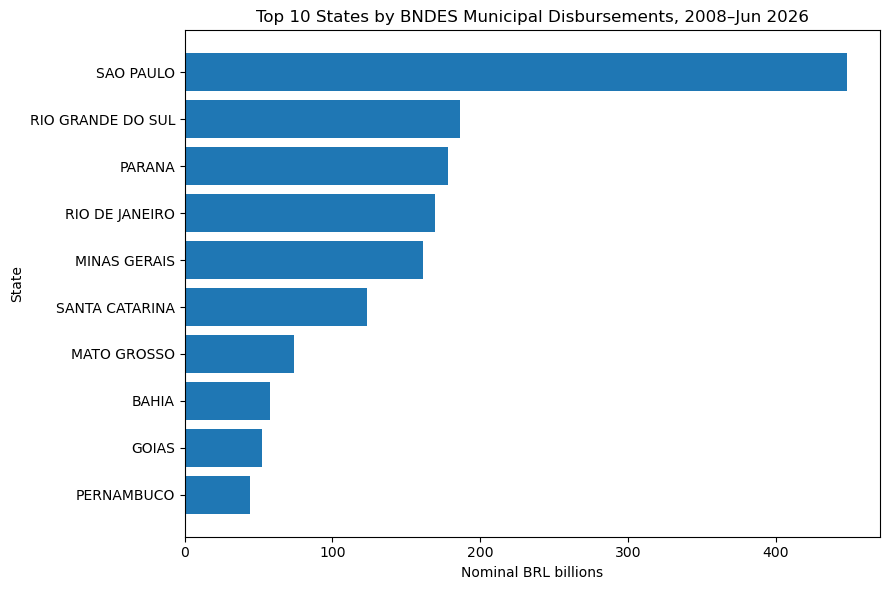

In [153]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    top_states["uf"],
    top_states["total_bilhoes"]
)

ax.set_title("Top 10 States by BNDES Municipal Disbursements, 2008–Jun 2026")
ax.set_xlabel("Nominal BRL billions")
ax.set_ylabel("State")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "top_states_disbursements.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Geographic Concentration

BNDES municipal disbursements are geographically concentrated.
São Paulo presents the largest accumulated value in the analyzed period,
followed by states such as Rio Grande do Sul, Paraná, Rio de Janeiro and
Minas Gerais.

These figures represent accumulated nominal disbursements and do not control
for differences in population, economic size or number of firms across states.

In [155]:
municipal_monthly["log_total_desembolsos"] = np.log1p(
    municipal_monthly["total_desembolsos"]
)

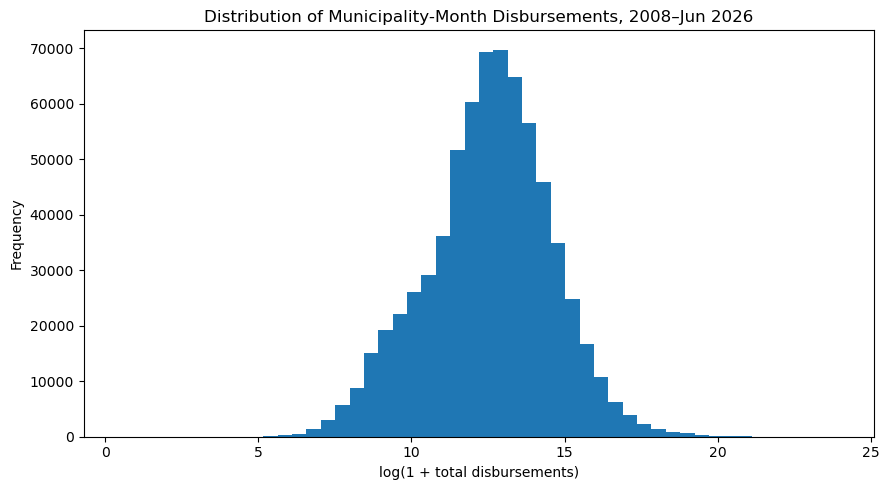

In [157]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    municipal_monthly["log_total_desembolsos"],
    bins=50
)

ax.set_title("Distribution of Municipality-Month Disbursements, 2008–Jun 2026")
ax.set_xlabel("log(1 + total disbursements)")
ax.set_ylabel("Frequency")

fig.tight_layout()

fig.savefig(
    FIGURES_DIR / "distribution_disbursements.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribution of Financing Values

Municipality-month disbursements are strongly right-skewed in their original
monetary scale. A logarithmic transformation is therefore used to make the
distribution easier to visualize.

The resulting distribution shows that most municipality-month observations
are concentrated around moderate financing values, while a relatively small
number of observations contain very large disbursements.

## 7. Creating a Reproducible Public Sample

The complete analytical dataset contains hundreds of thousands of
municipality-month observations.

To keep the repository lightweight and easy to reproduce, a subset of
municipalities is exported as a public sample while preserving their
available time-series observations.

In [159]:
sample_municipalities = (
    municipal_monthly["codigo_municipio"]
    .drop_duplicates()
    .sample(n=150, random_state=42)
)

public_sample = (
    municipal_monthly[
        municipal_monthly["codigo_municipio"].isin(sample_municipalities)
    ]
    .copy()
)

In [161]:
print("Municipalities in public sample:")
print(public_sample["codigo_municipio"].nunique())

print("\nObservations:")
print(len(public_sample))

print("\nPeriod:")
print(public_sample["data"].min())
print(public_sample["data"].max())

Municipalities in public sample:
150

Observations:
19022

Period:
2008-01-01 00:00:00
2026-06-01 00:00:00


In [163]:
public_sample = public_sample[
    [
        "data",
        "ano",
        "mes_num",
        "codigo_municipio",
        "uf",
        "municipio",
        "total_desembolsos",
        "numero_operacoes",
        "desembolso_medio"
    ]
].copy()

In [165]:
public_sample.to_csv(
    DATA_DIR / "municipal_bndes_sample.csv",
    index=False,
    encoding="utf-8-sig"
)

In [167]:
sample_path = DATA_DIR / "municipal_bndes_sample.csv"

print("File created:")
print(sample_path.exists())

print("\nFile size in MB:")
print(sample_path.stat().st_size / (1024 ** 2))

File created:
True

File size in MB:
1.3568248748779297
